In [1]:
import pandas as pd

# Replace with your CSV file path
pdf = pd.read_csv("AE FINAL.csv")

# Display first 5 rows
pdf.head()

,report_id,report_received_date,country,reporter_type,patient_age,is_missing_age,patient_sex,drug_name,drug_ndc_code,indication,...,outcome,onset_date,batch_id,manufacturing_site,dose_amount_mg,is_missing_dose,route_of_administration,concomitant_medications,causality_assessment,historical_ae_frequency
0,AE-2025-0046,2025-06-26,Brazil,Other,52,1,M,RHEUMATRIX,0781-5566-11,Rheumatoid Arthritis,...,Fatal,2025-06-26,B1090-B,MFG-BR-SAO-04,250,0,Topical,NaN,Probable,6
1,AE-2025-0008,2025-09-29,Japan,physician,52,1,M,VASCULIN,42858-7788-02,Deep Vein Thrombosis,...,Recovered,2025-09-29,B1008-C,MFG-DE-BER-02,25,1,Intramuscular,Atorvastatin,Possible,14
2,AE-2025-0030,2025-11-30,Australia,physician,21,0,F,NEUROLEX,0069-5678-02,Generalized Anxiety Disorder,...,Unknown,2025-11-30,B1059-C,MFG-IN-HYD-03,25,0,Intramuscular,Metformin,Probable,7
3,AE-2025-0067,2025-11-13,Brazil,Consumer,76,0,M,GLUCOMEND,00378-9012-10,Type 2 Diabetes,...,Fatal,2025-11-13,B1095-B,MFG-DE-BER-02,25,0,Oral,Metformin,Unrelated,11
4,AE-2025-0003,2025-07-13,United Kingdom,Nurse,52,1,Unknown,NEUROLEX,0069-5678-02,Generalized Anxiety Disorder,...,recovered,2025-07-13,B1037-A,MFG-DE-BER-02,25,1,Subcutaneous,Levothyroxine,Possible,7


In [2]:
# Check dataset information
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   report_id                81 non-null     str  
 1   report_received_date     81 non-null     str  
 2   country                  81 non-null     str  
 3   reporter_type            81 non-null     str  
 4   patient_age              81 non-null     int64
 5   is_missing_age           81 non-null     int64
 6   patient_sex              81 non-null     str  
 7   drug_name                81 non-null     str  
 8   drug_ndc_code            81 non-null     str  
 9   indication               81 non-null     str  
 10  adverse_event_term       81 non-null     str  
 11  event_seriousness        81 non-null     str  
 12  outcome                  81 non-null     str  
 13  onset_date               81 non-null     str  
 14  batch_id                 81 non-null     str  
 15  manufacturing_site 

In [3]:
# Check for missing values
pdf.isnull().sum()

report_id                   0
report_received_date        0
country                     0
reporter_type               0
patient_age                 0
is_missing_age              0
patient_sex                 0
drug_name                   0
drug_ndc_code               0
indication                  0
adverse_event_term          0
event_seriousness           0
outcome                     0
onset_date                  0
batch_id                    0
manufacturing_site          0
dose_amount_mg              0
is_missing_dose             0
route_of_administration     0
concomitant_medications    10
causality_assessment        0
historical_ae_frequency     0
dtype: int64

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [5]:
print(pdf.columns.tolist())

['report_id', 'report_received_date', 'country', 'reporter_type', 'patient_age', 'is_missing_age', 'patient_sex', 'drug_name', 'drug_ndc_code', 'indication', 'adverse_event_term', 'event_seriousness', 'outcome', 'onset_date', 'batch_id', 'manufacturing_site', 'dose_amount_mg', 'is_missing_dose', 'route_of_administration', 'concomitant_medications', 'causality_assessment', 'historical_ae_frequency']


In [6]:
# Standardize event_seriousness values
pdf["event_seriousness"] = (
    pdf["event_seriousness"]
    .astype(str)
    .str.strip()      # Remove leading/trailing spaces
    .str.title()      # Convert to Title Case
)

In [7]:
# Create label encoders
le_drug = LabelEncoder()
le_country = LabelEncoder()
le_reporter = LabelEncoder()
le_batch = LabelEncoder()
le_target = LabelEncoder()

# Encode categorical features
pdf["drug_name"] = le_drug.fit_transform(pdf["drug_name"])
pdf["country"] = le_country.fit_transform(pdf["country"])
pdf["reporter_type"] = le_reporter.fit_transform(pdf["reporter_type"])
pdf["batch_id"] = le_batch.fit_transform(pdf["batch_id"])

# Encode target
pdf["event_seriousness"] = le_target.fit_transform(pdf["event_seriousness"])

# Display first rows
pdf.head()

,report_id,report_received_date,country,reporter_type,patient_age,is_missing_age,patient_sex,drug_name,drug_ndc_code,indication,...,outcome,onset_date,batch_id,manufacturing_site,dose_amount_mg,is_missing_dose,route_of_administration,concomitant_medications,causality_assessment,historical_ae_frequency
0,AE-2025-0046,2025-06-26,1,3,52,1,M,7,0781-5566-11,Rheumatoid Arthritis,...,Fatal,2025-06-26,62,MFG-BR-SAO-04,250,0,Topical,NaN,Probable,6
1,AE-2025-0008,2025-09-29,6,6,52,1,M,8,42858-7788-02,Deep Vein Thrombosis,...,Recovered,2025-09-29,5,MFG-DE-BER-02,25,1,Intramuscular,Atorvastatin,Possible,14
2,AE-2025-0030,2025-11-30,0,6,21,0,F,4,0069-5678-02,Generalized Anxiety Disorder,...,Unknown,2025-11-30,42,MFG-IN-HYD-03,25,0,Intramuscular,Metformin,Probable,7
3,AE-2025-0067,2025-11-13,1,0,76,0,M,2,00378-9012-10,Type 2 Diabetes,...,Fatal,2025-11-13,66,MFG-DE-BER-02,25,0,Oral,Metformin,Unrelated,11
4,AE-2025-0003,2025-07-13,8,2,52,1,Unknown,4,0069-5678-02,Generalized Anxiety Disorder,...,recovered,2025-07-13,28,MFG-DE-BER-02,25,1,Subcutaneous,Levothyroxine,Possible,7


In [8]:
X = pdf[[
    'patient_age',
    'drug_name',
    'dose_amount_mg',
    'country',
    'reporter_type',
    'batch_id',
    'historical_ae_frequency'
]]

y = pdf['event_seriousness']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 64
Testing Samples  : 17


In [10]:
# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [11]:
# Predict on test data
y_pred = log_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1]


In [12]:
from sklearn.metrics import f1_score
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.47058823529411764
Precision: 0.46638655462184875
Recall   : 0.47058823529411764
F1 Score : 0.46687306501547987


# Logistic Regression

In [13]:
# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")
# Predict on test data
y_pred = log_model.predict(X_test)

print("Predictions:")
print(y_pred)

from sklearn.metrics import f1_score
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Logistic Regression model trained successfully!
Predictions:
[1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1]
Accuracy : 0.47058823529411764
Precision: 0.46638655462184875
Recall   : 0.47058823529411764
F1 Score : 0.46687306501547987


# Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

print("Predictions:")
print(y_pred_rf)

# Evaluate the model
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_rf, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest model trained successfully!
Predictions:
[1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0]
Accuracy : 0.47058823529411764
Precision: 0.4738562091503268
Recall   : 0.47058823529411764
F1 Score : 0.47058823529411764

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.44      0.50      0.47         8

    accuracy                           0.47        17
   macro avg       0.47      0.47      0.47        17
weighted avg       0.47      0.47      0.47        17


Confusion Matrix
[[4 5]
 [4 4]]


# XGBoost

In [15]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Convert numeric columns
pdf["patient_age"] = pd.to_numeric(pdf["patient_age"], errors="coerce")
pdf["dose_amount_mg"] = pd.to_numeric(pdf["dose_amount_mg"], errors="coerce")
pdf["historical_ae_frequency"] = pd.to_numeric(pdf["historical_ae_frequency"], errors="coerce")

# Features and Target
X = pdf[
    [
        "patient_age",
        "drug_name",
        "dose_amount_mg",
        "country",
        "reporter_type",
        "batch_id",
        "historical_ae_frequency",
    ]
]

y = pdf["event_seriousness"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Train XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

print("\nAccuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_xgb, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_xgb, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost model trained successfully!

Accuracy : 0.35294117647058826
Precision: 0.35539215686274506
Recall   : 0.35294117647058826
F1 Score : 0.35294117647058826

Classification Report
              precision    recall  f1-score   support

           0       0.38      0.33      0.35         9
           1       0.33      0.38      0.35         8

    accuracy                           0.35        17
   macro avg       0.35      0.35      0.35        17
weighted avg       0.36      0.35      0.35        17


Confusion Matrix
[[3 6]
 [5 3]]


Logistic Regression model trained successfully!

Accuracy : 0.47058823529411764
Precision: 0.46638655462184875
Recall   : 0.47058823529411764
F1 Score : 0.46687306501547987
ROC-AUC  : 0.2777777777777778

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.43      0.38      0.40         8

    accuracy                           0.47        17
   macro avg       0.46      0.47      0.46        17
weighted avg       0.47      0.47      0.47        17


Confusion Matrix
[[5 4]
 [5 3]]


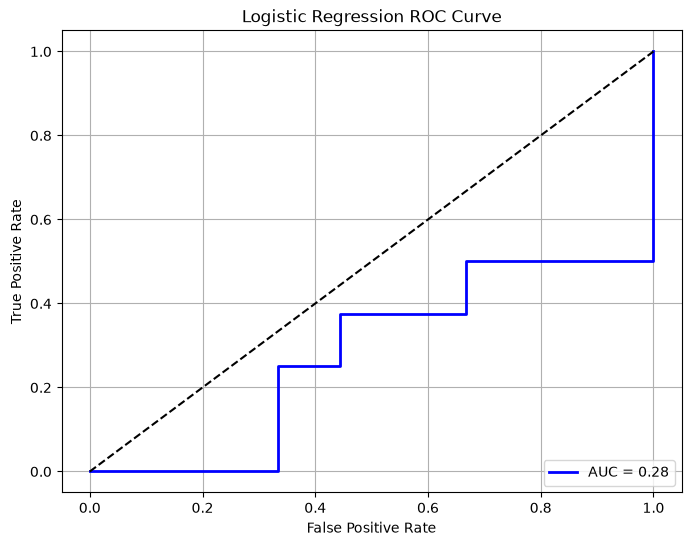

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# -----------------------------
# Convert numeric columns
# -----------------------------
pdf["patient_age"] = pd.to_numeric(pdf["patient_age"], errors="coerce")
pdf["dose_amount_mg"] = pd.to_numeric(pdf["dose_amount_mg"], errors="coerce")
pdf["historical_ae_frequency"] = pd.to_numeric(
    pdf["historical_ae_frequency"],
    errors="coerce"
)

# -----------------------------
# Features and Target
# -----------------------------
X = pdf[
    [
        "patient_age",
        "drug_name",
        "dose_amount_mg",
        "country",
        "reporter_type",
        "batch_id",
        "historical_ae_frequency",
    ]
]

y = pdf["event_seriousness"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------------
# Logistic Regression Model
# -----------------------------
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

# -----------------------------
# Predictions
# -----------------------------
y_pred = log_model.predict(X_test)

# Probability of positive class
y_prob = log_model.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation Metrics
# -----------------------------
print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

# -----------------------------
# ROC-AUC
# -----------------------------
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC  :", roc_auc)

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# -----------------------------
# Confusion Matrix
# -----------------------------
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

Random Forest model trained successfully!

Predictions:
[1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0]

Accuracy : 0.47058823529411764
Precision: 0.4738562091503268
Recall   : 0.47058823529411764
F1 Score : 0.47058823529411764
ROC-AUC  : 0.5416666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.44      0.50      0.47         8

    accuracy                           0.47        17
   macro avg       0.47      0.47      0.47        17
weighted avg       0.47      0.47      0.47        17


Confusion Matrix
[[4 5]
 [4 4]]


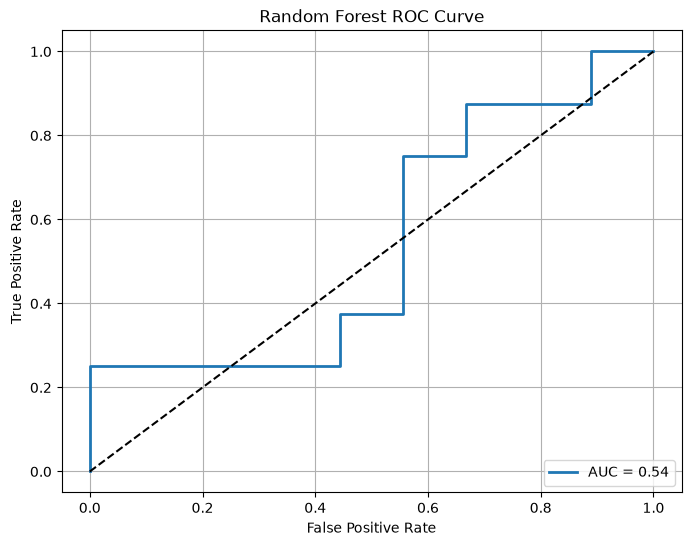

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Probability of positive class
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nPredictions:")
print(y_pred_rf)

# Evaluation Metrics
print("\nAccuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_rf, average="weighted"))

# Binary ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC  :", roc_auc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

XGBoost model trained successfully!

Accuracy : 0.35294117647058826
Precision: 0.35539215686274506
Recall   : 0.35294117647058826
F1 Score : 0.35294117647058826
ROC-AUC  : 0.4166666666666667

Classification Report
              precision    recall  f1-score   support

           0       0.38      0.33      0.35         9
           1       0.33      0.38      0.35         8

    accuracy                           0.35        17
   macro avg       0.35      0.35      0.35        17
weighted avg       0.36      0.35      0.35        17


Confusion Matrix
[[3 6]
 [5 3]]


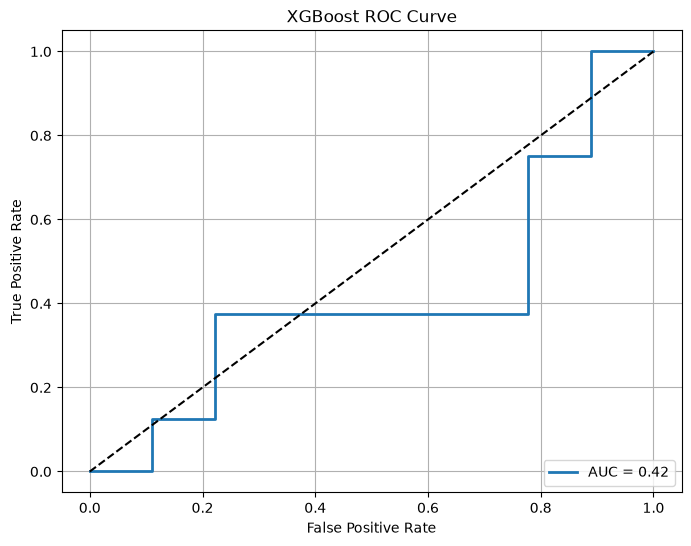

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

# Convert numeric columns
pdf["patient_age"] = pd.to_numeric(pdf["patient_age"], errors="coerce")
pdf["dose_amount_mg"] = pd.to_numeric(pdf["dose_amount_mg"], errors="coerce")
pdf["historical_ae_frequency"] = pd.to_numeric(
    pdf["historical_ae_frequency"],
    errors="coerce"
)

# Features
X = pdf[
    [
        "patient_age",
        "drug_name",
        "dose_amount_mg",
        "country",
        "reporter_type",
        "batch_id",
        "historical_ae_frequency",
    ]
]

# Target
y = pdf["event_seriousness"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# XGBoost Model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Probability of positive class
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("\nAccuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_xgb, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_xgb, average="weighted"))

# Binary ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC  :", roc_auc)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [19]:
print(pdf.columns.tolist())

['report_id', 'report_received_date', 'country', 'reporter_type', 'patient_age', 'is_missing_age', 'patient_sex', 'drug_name', 'drug_ndc_code', 'indication', 'adverse_event_term', 'event_seriousness', 'outcome', 'onset_date', 'batch_id', 'manufacturing_site', 'dose_amount_mg', 'is_missing_dose', 'route_of_administration', 'concomitant_medications', 'causality_assessment', 'historical_ae_frequency']


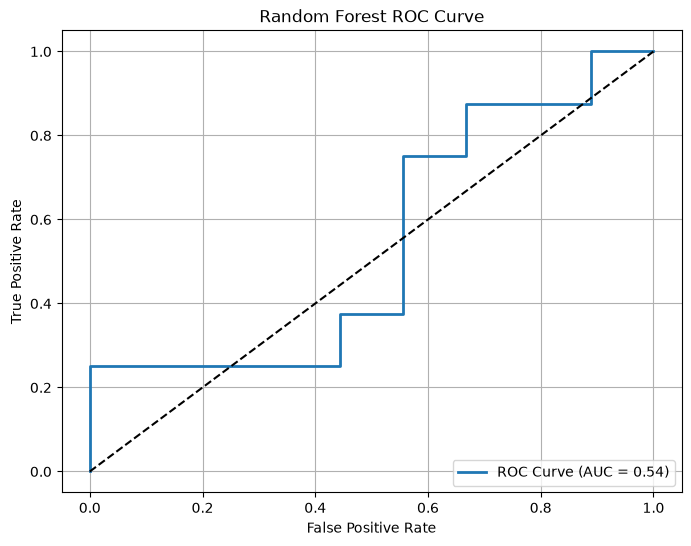

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of positive class
y_score = rf_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [21]:
y_score = rf_model.predict_proba(X_test)[:, 1]

## Overall Comparison

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_xgb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_xgb, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted")
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.470588   0.466387  0.470588  0.466873  0.277778
1        Random Forest  0.470588   0.473856  0.470588  0.470588  0.541667
2              XGBoost  0.352941   0.355392  0.352941  0.352941  0.416667


# PLOTS

## Bar Plot

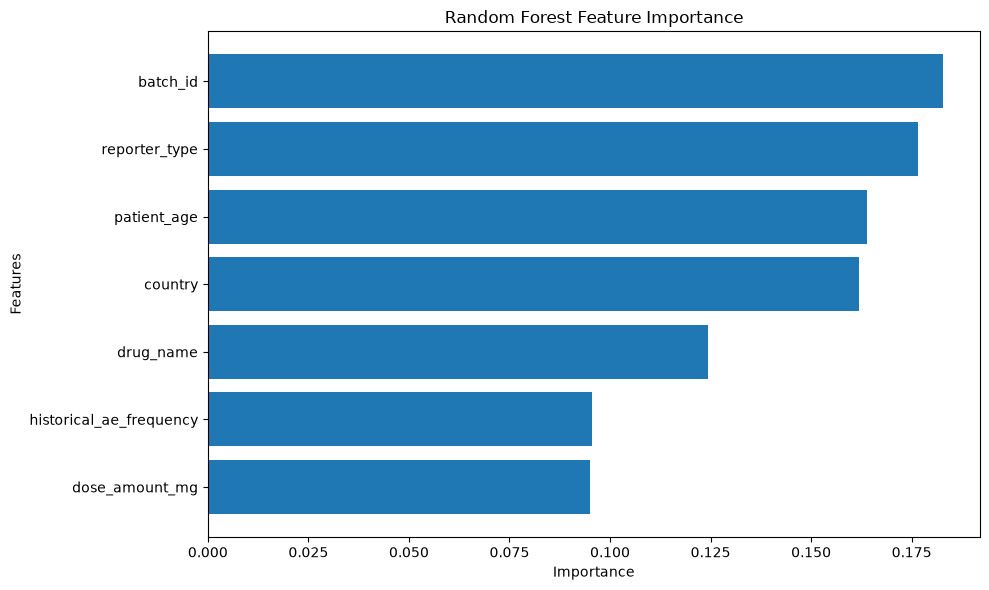

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## ROC Curve Comparison

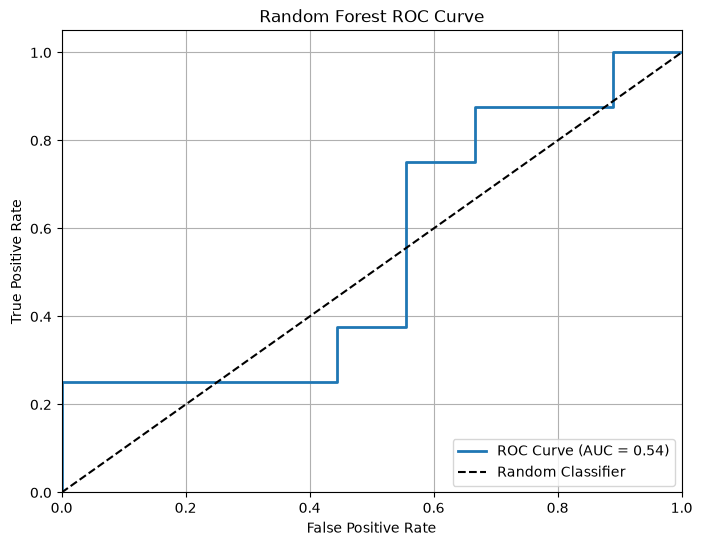

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of the positive class (Class 1)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.2f})"
)

# Random classifier line
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## Confusion Matrix

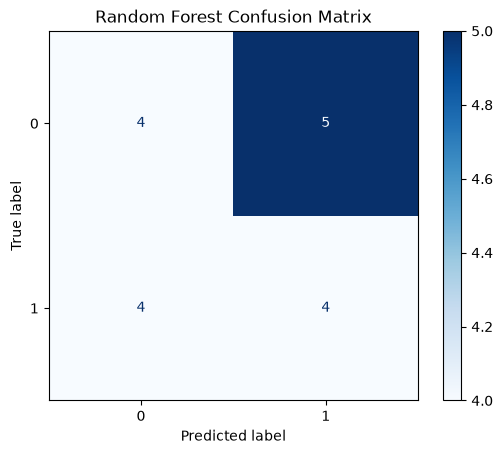

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Pie Chart

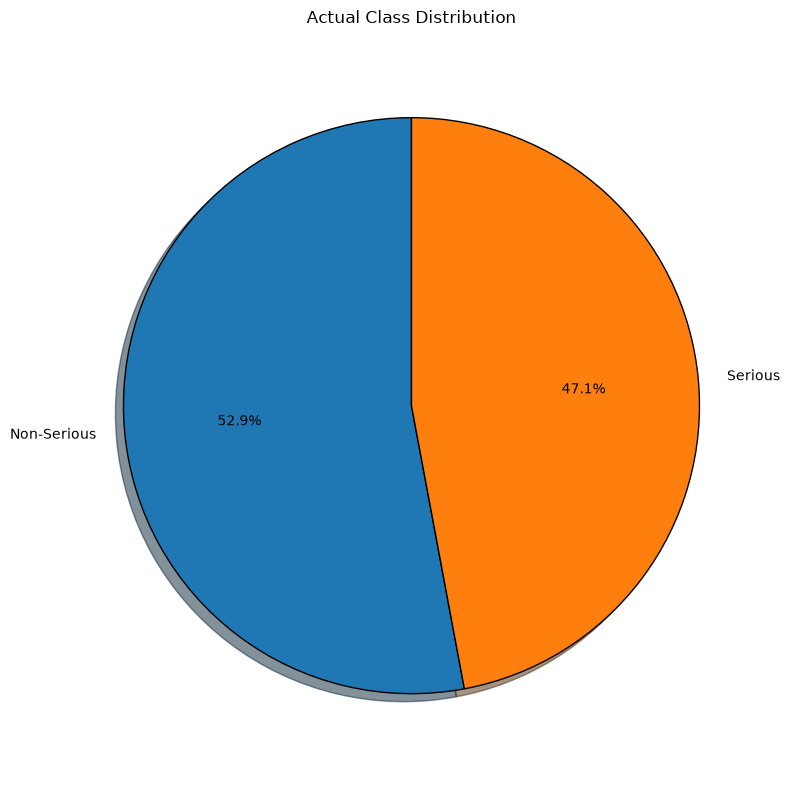

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert encoded labels back to original class names
actual_classes = le_target.inverse_transform(y_test)

# Count each class
class_counts = pd.Series(actual_classes).value_counts()

# Plot Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor':'black'}
)

plt.title("Actual Class Distribution")

plt.axis('equal')

plt.tight_layout()

plt.savefig("classification_actual_pie_chart.png", dpi=300)

plt.show()

# SHAP

## SHAP Bar Plot

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


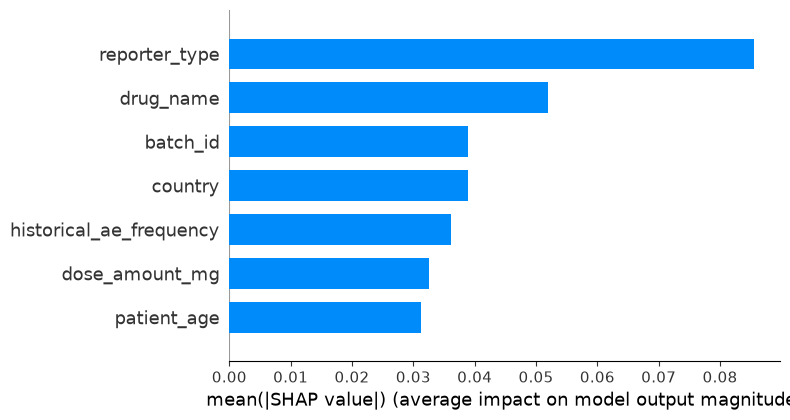

In [27]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

## SHAP Summary Plot

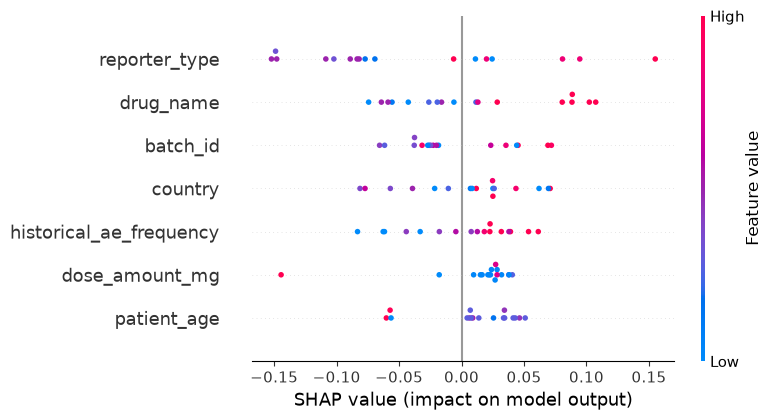

In [28]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values[:, :, 1], X_test)

## SHAP Waterfall Plot

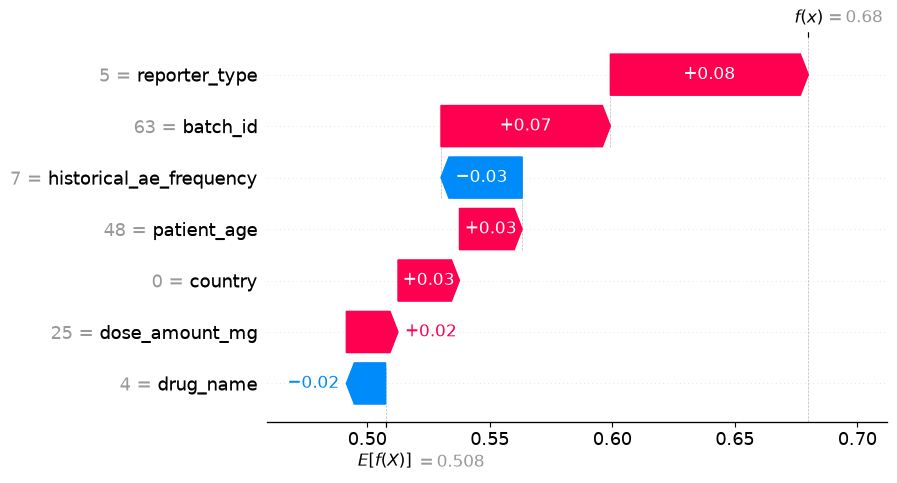

In [29]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# First test sample
shap.plots.waterfall(shap_values[0, :, 1])

## SHAP Force Plot

In [30]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values.values[0, :, 1],
    X_test.iloc[0]
)

## SHAP Violin Plot

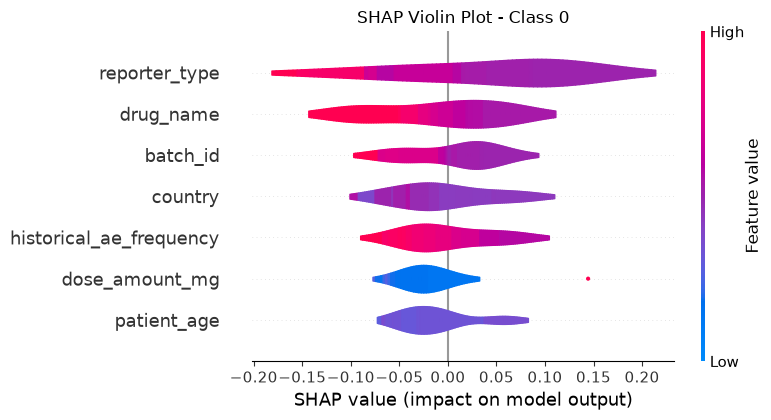

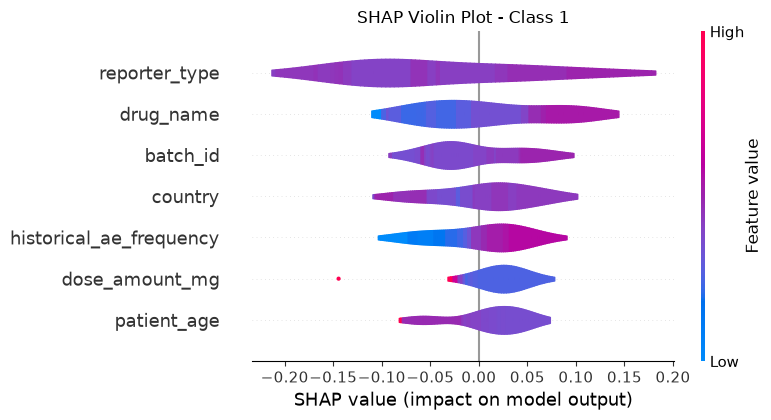

In [31]:
for i in range(shap_values.values.shape[2]):

    shap_class = shap.Explanation(
        values=shap_values.values[:, :, i],
        base_values=shap_values.base_values[:, i],
        data=X_test.values,
        feature_names=X_test.columns
    )

    plt.figure(figsize=(10,6))

    shap.plots.violin(
        shap_class,
        show=False
    )

    plt.title(f"SHAP Violin Plot - Class {i}")

    plt.tight_layout()

    plt.show()

In [32]:
best_model = rf_model
best_pred = y_pred_rf
best_prob = rf_model.predict_proba(X_test)

In [34]:
import os
import joblib

# =====================================================
# SELECT BEST MODEL
# =====================================================

# Random Forest (Default)
# best_model = rf_model
# best_pred = y_pred_rf
# best_prob = rf_model.predict_proba(X_test)

# Logistic Regression
# best_model = log_model
# best_pred = y_pred
# best_prob = log_model.predict_proba(X_test)

# XGBoost
# best_model = xgb_model
# best_pred = y_pred_xgb
# best_prob = xgb_model.predict_proba(X_test)

# =====================================================
# CREATE FOLDER STRUCTURE
# =====================================================

BASE_DIR = "models"
ROOT_DIR = os.path.join(BASE_DIR, "classification")

MODEL_DIR = os.path.join(ROOT_DIR, "model")
METRIC_DIR = os.path.join(ROOT_DIR, "metrics")
PLOT_DIR = os.path.join(ROOT_DIR, "plots")
PREDICTION_DIR = os.path.join(ROOT_DIR, "predictions")
SHAP_DIR = os.path.join(ROOT_DIR, "shap")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(PREDICTION_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

print("Classification folders created successfully.")

# =====================================================
# SAVE BEST MODEL
# =====================================================

joblib.dump(
    best_model,
    os.path.join(
        MODEL_DIR,
        "classification_model.pkl"
    )
)

print("Best model saved.")

# =====================================================
# SAVE LABEL ENCODERS
# =====================================================

joblib.dump(
    le_drug,
    os.path.join(
        MODEL_DIR,
        "le_drug.pkl"
    )
)

joblib.dump(
    le_country,
    os.path.join(
        MODEL_DIR,
        "le_country.pkl"
    )
)

joblib.dump(
    le_reporter,
    os.path.join(
        MODEL_DIR,
        "le_reporter.pkl"
    )
)

joblib.dump(
    le_batch,
    os.path.join(
        MODEL_DIR,
        "le_batch.pkl"
    )
)

joblib.dump(
    le_target,
    os.path.join(
        MODEL_DIR,
        "le_target.pkl"
    )
)

print("Label encoders saved.")

# =====================================================
# SAVE FEATURE COLUMNS
# =====================================================

joblib.dump(
    list(X.columns),
    os.path.join(
        MODEL_DIR,
        "feature_columns.pkl"
    )
)

print("Feature columns saved.")

print("\n===================================")
print("PART 1A COMPLETED")
print("===================================")
print("✔ Folder Structure")
print("✔ Best Model")
print("✔ Label Encoders")
print("✔ Feature Columns")
print("===================================")

Classification folders created successfully.
Best model saved.
Label encoders saved.
Feature columns saved.

PART 1A COMPLETED
✔ Folder Structure
✔ Best Model
✔ Label Encoders
✔ Feature Columns


In [35]:
# =====================================================
# PART 1B
# SAVE METRICS, REPORTS, PREDICTIONS & SHAP OBJECTS
# =====================================================

import json
import joblib
import shap
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

# =====================================================
# METRICS
# =====================================================

metrics = {

    "accuracy": float(
        accuracy_score(
            y_test,
            best_pred
        )
    ),

    "precision_macro": float(
        precision_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "recall_macro": float(
        recall_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "f1_macro": float(
        f1_score(
            y_test,
            best_pred,
            average="macro"
        )
    ),

    "precision_weighted": float(
        precision_score(
            y_test,
            best_pred,
            average="weighted"
        )
    ),

    "recall_weighted": float(
        recall_score(
            y_test,
            best_pred,
            average="weighted"
        )
    ),

    "f1_weighted": float(
        f1_score(
            y_test,
            best_pred,
            average="weighted"
        )
    )

}

# Add log loss only if probabilities exist

try:

    metrics["log_loss"] = float(

        log_loss(
            y_test,
            best_prob
        )

    )

except:

    pass

# =====================================================
# SAVE METRICS
# =====================================================

with open(

    os.path.join(
        METRIC_DIR,
        "metrics.json"
    ),

    "w"

) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("Metrics Saved")

# =====================================================
# SAVE CLASSIFICATION REPORT
# =====================================================

report = classification_report(
    y_test,
    best_pred
)

with open(

    os.path.join(
        METRIC_DIR,
        "classification_report.txt"
    ),

    "w"

) as f:

    f.write(report)

print("Classification Report Saved")

# =====================================================
# SAVE CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

joblib.dump(

    cm,

    os.path.join(
        METRIC_DIR,
        "confusion_matrix.pkl"
    )

)

print("Confusion Matrix Saved")

# =====================================================
# SAVE PREDICTIONS
# =====================================================

prediction_df = pd.DataFrame({

    "Actual":

        le_target.inverse_transform(
            y_test
        ),

    "Predicted":

        le_target.inverse_transform(
            best_pred
        )

})

prediction_df.to_csv(

    os.path.join(
        PREDICTION_DIR,
        "predictions.csv"
    ),

    index=False

)

print("Predictions Saved")

# =====================================================
# CREATE SHAP EXPLAINER
# =====================================================

try:

    if best_model == rf_model:

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_values = explainer(
            X_test
        )

    elif best_model == xgb_model:

        explainer = shap.TreeExplainer(
            best_model
        )

        shap_values = explainer(
            X_test
        )

    else:

        explainer = shap.LinearExplainer(
            best_model,
            X_train
        )

        shap_values = explainer(
            X_test
        )

    joblib.dump(

        explainer,

        os.path.join(
            SHAP_DIR,
            "shap_explainer.pkl"
        )

    )

    joblib.dump(

        shap_values,

        os.path.join(
            SHAP_DIR,
            "shap_values.pkl"
        )

    )

    print("SHAP Objects Saved")

except Exception as e:

    print("SHAP Error :", e)

print("\n=====================================")
print("PART 1B COMPLETED")
print("=====================================")
print("✔ Metrics JSON")
print("✔ Classification Report")
print("✔ Confusion Matrix")
print("✔ Predictions CSV")
print("✔ SHAP Explainer")
print("✔ SHAP Values")
print("=====================================")

Metrics Saved
Classification Report Saved
Confusion Matrix Saved
Predictions Saved
SHAP Objects Saved

PART 1B COMPLETED
✔ Metrics JSON
✔ Classification Report
✔ Confusion Matrix
✔ Predictions CSV
✔ SHAP Explainer
✔ SHAP Values


In [36]:
# =====================================================
# PART 2
# ROC CURVES + FEATURE IMPORTANCE + CM + PIE CHART
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

PLOT_DIR = os.path.join("models", "classification", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# ROC CURVE - LOGISTIC REGRESSION
# =====================================================

y_prob_log = log_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob_log)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "roc_logistic.png"
    ),
    dpi=300
)

plt.close()

print("ROC Logistic Saved")

# =====================================================
# ROC CURVE - RANDOM FOREST
# =====================================================

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob_rf)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "roc_random_forest.png"
    ),

    dpi=300

)

plt.close()

print("ROC Random Forest Saved")

# =====================================================
# ROC CURVE - XGBOOST
# =====================================================

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob_xgb)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "roc_xgboost.png"
    ),

    dpi=300

)

plt.close()

print("ROC XGBoost Saved")

# =====================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf_model.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "rf_feature_importance_bar.png"
    ),

    dpi=300

)

plt.close()

print("Feature Importance Saved")

# =====================================================
# CONFUSION MATRIX HEATMAP
# =====================================================

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    best_pred,

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "confusion_matrix_heatmap.png"
    ),

    dpi=300

)

plt.close()

print("Confusion Matrix Saved")

# =====================================================
# PIE CHART
# =====================================================

actual = le_target.inverse_transform(y_test)

counts = pd.Series(actual).value_counts()

plt.figure(figsize=(7,7))

plt.pie(

    counts,

    labels=counts.index,

    autopct="%1.1f%%",

    startangle=90,

    shadow=True,

    wedgeprops={
        "edgecolor":"black"
    }

)

plt.title("Actual Class Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "actual_class_distribution.png"
    ),

    dpi=300

)

plt.close()

print("Pie Chart Saved")

print("\n===================================")
print("PART 2 COMPLETED")
print("===================================")
print("✔ ROC Logistic")
print("✔ ROC Random Forest")
print("✔ ROC XGBoost")
print("✔ RF Feature Importance")
print("✔ Confusion Matrix")
print("✔ Actual Class Pie Chart")
print("===================================")

ROC Logistic Saved
ROC Random Forest Saved
ROC XGBoost Saved
Feature Importance Saved
Confusion Matrix Saved
Pie Chart Saved

PART 2 COMPLETED
✔ ROC Logistic
✔ ROC Random Forest
✔ ROC XGBoost
✔ RF Feature Importance
✔ Confusion Matrix
✔ Actual Class Pie Chart


<Figure size 700x600 with 0 Axes>

In [37]:
# =====================================================
# PART 3
# SHAP SUMMARY, BAR, WATERFALL & FORCE PLOTS
# =====================================================

import os
import joblib
import shap
import matplotlib.pyplot as plt

SHAP_DIR = os.path.join("models", "classification", "shap")
PLOT_DIR = os.path.join("models", "classification", "plots")

os.makedirs(SHAP_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# CREATE SHAP EXPLAINER
# =====================================================

explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)

# =====================================================
# SAVE SHAP OBJECTS
# =====================================================

joblib.dump(
    explainer,
    os.path.join(
        SHAP_DIR,
        "shap_explainer.pkl"
    )
)

joblib.dump(
    shap_values,
    os.path.join(
        SHAP_DIR,
        "shap_values.pkl"
    )
)

print("SHAP Objects Saved")

# =====================================================
# SHAP SUMMARY (BEESWARM)
# =====================================================

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_summary_beeswarm.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP Summary Saved")

# =====================================================
# SHAP SUMMARY BAR
# =====================================================

plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values[:, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_summary_bar.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP Bar Saved")

# =====================================================
# SHAP WATERFALL
# =====================================================

plt.figure(figsize=(10,6))

shap.plots.waterfall(
    shap_values[0, :, 1],
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_waterfall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Waterfall Saved")

# =====================================================
# SHAP FORCE PLOT
# =====================================================

shap.initjs()

force_plot = shap.force_plot(

    explainer.expected_value[1],

    shap_values.values[0, :, 1],

    X_test.iloc[0],

    matplotlib=True,

    show=False

)

plt.savefig(

    os.path.join(
        PLOT_DIR,
        "shap_force_plot.png"
    ),

    dpi=300,

    bbox_inches="tight"

)

plt.close()

print("Force Plot Saved")

print("\n=======================================")
print("PART 3 COMPLETED")
print("=======================================")
print("✔ SHAP Explainer")
print("✔ SHAP Values")
print("✔ SHAP Summary (Beeswarm)")
print("✔ SHAP Summary Bar")
print("✔ SHAP Waterfall")
print("✔ SHAP Force Plot")
print("=======================================")

SHAP Objects Saved
SHAP Summary Saved
SHAP Bar Saved
Waterfall Saved


Force Plot Saved

PART 3 COMPLETED
✔ SHAP Explainer
✔ SHAP Values
✔ SHAP Summary (Beeswarm)
✔ SHAP Summary Bar
✔ SHAP Waterfall
✔ SHAP Force Plot


In [38]:
# =====================================================
# PART 4
# SHAP VIOLIN, DECISION & FINAL SUMMARY
# =====================================================

import os
import shap
import matplotlib.pyplot as plt

PLOT_DIR = os.path.join("models", "classification", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# =====================================================
# SHAP VIOLIN PLOT (CLASS-WISE)
# =====================================================

n_classes = shap_values.values.shape[2]

for i in range(n_classes):

    explanation = shap.Explanation(

        values=shap_values.values[:, :, i],

        base_values=shap_values.base_values[:, i],

        data=X_test.values,

        feature_names=X_test.columns

    )

    plt.figure(figsize=(10,6))

    shap.plots.violin(
        explanation,
        show=False
    )

    plt.title(f"SHAP Violin Plot - {le_target.classes_[i]}")

    plt.tight_layout()

    plt.savefig(

        os.path.join(

            PLOT_DIR,

            f"shap_violin_class_{le_target.classes_[i]}.png"

        ),

        dpi=300,

        bbox_inches="tight"

    )

    plt.close()

print("Class-wise Violin Plots Saved")

# =====================================================
# SHAP DECISION PLOT
# =====================================================

try:

    shap.decision_plot(

        explainer.expected_value[1],

        shap_values.values[:, :, 1],

        X_test,

        show=False

    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            PLOT_DIR,
            "shap_decision_plot.png"
        ),

        dpi=300,

        bbox_inches="tight"

    )

    plt.close()

    print("Decision Plot Saved")

except Exception as e:

    print("Decision Plot not supported:", e)

# =====================================================
# SAVE SHAP EXPECTED VALUE
# =====================================================

import joblib

joblib.dump(

    explainer.expected_value,

    os.path.join(

        "models",

        "classification",

        "shap",

        "expected_value.pkl"

    )

)

print("Expected Value Saved")

# =====================================================
# FINAL SUMMARY
# =====================================================

print("\n" + "="*65)
print("        CLASSIFICATION MODEL DEPLOYMENT COMPLETED")
print("="*65)

print("\nFolder Structure:\n")

print("models/")
print("└── classification/")
print("    ├── model/")
print("    ├── metrics/")
print("    ├── plots/")
print("    ├── predictions/")
print("    └── shap/")

print("\nArtifacts Saved")
print("-"*65)

print("MODELS")
print("✔ classification_model.pkl")
print("✔ le_drug.pkl")
print("✔ le_country.pkl")
print("✔ le_reporter.pkl")
print("✔ le_batch.pkl")
print("✔ le_target.pkl")
print("✔ feature_columns.pkl")

print("\nMETRICS")
print("✔ metrics.json")
print("✔ classification_report.txt")
print("✔ confusion_matrix.pkl")

print("\nPREDICTIONS")
print("✔ predictions.csv")

print("\nROC CURVES")
print("✔ Logistic Regression")
print("✔ Random Forest")
print("✔ XGBoost")

print("\nPLOTS")
print("✔ RF Feature Importance")
print("✔ Confusion Matrix Heatmap")
print("✔ Actual Class Distribution Pie Chart")

print("\nSHAP")
print("✔ SHAP Explainer")
print("✔ SHAP Values")
print("✔ Expected Value")
print("✔ SHAP Summary")
print("✔ SHAP Summary Bar")
print("✔ SHAP Beeswarm")
print("✔ SHAP Waterfall")
print("✔ SHAP Force Plot")
print("✔ SHAP Violin (Class-wise)")
print("✔ SHAP Decision Plot (if supported)")

print("\n" + "="*65)
print("DEPLOYMENT FINISHED SUCCESSFULLY")
print("="*65)

Class-wise Violin Plots Saved
Decision Plot Saved
Expected Value Saved

        CLASSIFICATION MODEL DEPLOYMENT COMPLETED

Folder Structure:

models/
└── classification/
    ├── model/
    ├── metrics/
    ├── plots/
    ├── predictions/
    └── shap/

Artifacts Saved
-----------------------------------------------------------------
MODELS
✔ classification_model.pkl
✔ le_drug.pkl
✔ le_country.pkl
✔ le_reporter.pkl
✔ le_batch.pkl
✔ le_target.pkl
✔ feature_columns.pkl

METRICS
✔ metrics.json
✔ classification_report.txt
✔ confusion_matrix.pkl

PREDICTIONS
✔ predictions.csv

ROC CURVES
✔ Logistic Regression
✔ Random Forest
✔ XGBoost

PLOTS
✔ RF Feature Importance
✔ Confusion Matrix Heatmap
✔ Actual Class Distribution Pie Chart

SHAP
✔ SHAP Explainer
✔ SHAP Values
✔ Expected Value
✔ SHAP Summary
✔ SHAP Summary Bar
✔ SHAP Beeswarm
✔ SHAP Waterfall
✔ SHAP Force Plot
✔ SHAP Violin (Class-wise)
✔ SHAP Decision Plot (if supported)

DEPLOYMENT FINISHED SUCCESSFULLY


In [ ]:
''' 
import os
import json
import joblib
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss
)

# =====================================================
# SELECT BEST MODEL
# =====================================================

# Change only these 3 lines if another model is best
best_model = rf_model
best_pred = y_pred_rf
best_prob = rf_model.predict_proba(X_test)

# =====================================================
# CREATE FOLDER
# =====================================================

os.makedirs('models', exist_ok=True)

# =====================================================
# SAVE MODEL
# =====================================================

joblib.dump(best_model,
            'models/classification_model.pkl')

# =====================================================
# SAVE ENCODERS
# =====================================================

joblib.dump(le_drug,
            'models/le_drug.pkl')

joblib.dump(le_country,
            'models/le_country.pkl')

joblib.dump(le_reporter,
            'models/le_reporter.pkl')

joblib.dump(le_batch,
            'models/le_batch.pkl')

joblib.dump(le_target,
            'models/le_target.pkl')

# =====================================================
# SAVE FEATURE NAMES
# =====================================================

joblib.dump(
    list(X.columns),
    'models/feature_columns.pkl'
)

# =====================================================
# SAVE METRICS
# =====================================================

metrics = {

    'accuracy':
        float(accuracy_score(y_test, best_pred)),

    'precision':
        float(precision_score(
            y_test,
            best_pred,
            average='weighted'
        )),

    'recall':
        float(recall_score(
            y_test,
            best_pred,
            average='weighted'
        )),

    'f1_score':
        float(f1_score(
            y_test,
            best_pred,
            average='weighted'
        )),

    'log_loss':
        float(log_loss(
            y_test,
            best_prob
        ))

}

with open(
    'models/classification_metrics.json',
    'w'
) as f:

    json.dump(metrics, f, indent=4)

# =====================================================
# SAVE SHAP EXPLAINER
# =====================================================

try:

    explainer = shap.Explainer(
        best_model,
        X_train
    )

    joblib.dump(
        explainer,
        'models/classification_shap.pkl'
    )

    print('SHAP Explainer Saved')

except Exception as e:

    print('SHAP could not be saved:', e)

# =====================================================
# SAVE REPORT
# =====================================================

with open(
    'models/classification_report.txt',
    'w'
) as f:

    f.write(
        classification_report(
            y_test,
            best_pred
        )
    )

joblib.dump(
    confusion_matrix(
        y_test,
        best_pred
    ),
    'models/confusion_matrix.pkl'
)

print('\n=================================')
print('Classification Model Saved')
print('=================================')
print('Model')
print('Encoders')
print('Feature Columns')
print('Metrics')
print('Classification Report')
print('Confusion Matrix')
print('SHAP Explainer')
print('=================================')
'''

SHAP Explainer Saved

Classification Model Saved
Model
Encoders
Feature Columns
Metrics
Classification Report
Confusion Matrix
SHAP Explainer


In [ ]:
# =====================================================
# SAVE SHAP
# =====================================================

import matplotlib.pyplot as plt

try:

    explainer = shap.Explainer(best_model, X_train)

    shap_values = explainer(X_test)

    # Save explainer
    joblib.dump(
        explainer,
        'models/classification_shap_explainer.pkl'
    )

    # Save SHAP values
    joblib.dump(
        shap_values,
        'models/classification_shap_values.pkl'
    )

    # Summary Plot
    plt.figure(figsize=(10,6))

    shap.plots.beeswarm(
        shap_values,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        'models/classification_shap_summary.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    # Bar Plot
    plt.figure(figsize=(10,6))

    shap.plots.bar(
        shap_values,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        'models/classification_shap_bar.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    print('SHAP Explainer Saved')
    print('SHAP Values Saved')
    print('SHAP Summary Plot Saved')
    print('SHAP Bar Plot Saved')

except Exception as e:

    print('SHAP Error:', e)

SHAP Error: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!


<Figure size 1000x600 with 0 Axes>